# Financial Text Classification — Reuters-21578
## Multi-Label Classification Pipeline
**Embeddings:** BoW · TF-IDF · Word2Vec · GloVe · FastText  
**Models:** Logistic Regression · Naive Bayes · Decision Tree · Random Forest · SVM · KNN · Bagging · AdaBoost · Gradient Boosting · XGBoost  
**Metric:** Accuracy · Micro F1 · Macro F1

## Install & Import

In [1]:
!pip install -q gensim xgboost scikit-learn pandas numpy matplotlib seaborn

In [2]:
import warnings, os, re, time, requests, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Sklearn — feature engineering
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split, GridSearchCV

# Sklearn — models
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, BaggingClassifier,
    AdaBoostClassifier, GradientBoostingClassifier
)
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

# Sklearn — evaluation
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, multilabel_confusion_matrix
)

# Gensim — word embeddings
from gensim.models import Word2Vec, FastText, KeyedVectors

# XGBoost
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost not available, skipping.')

# Scipy sparse
from scipy.sparse import issparse

warnings.filterwarnings('ignore')
np.random.seed(42)
print('All imports OK')

All imports OK


## 1. Load & Preprocess Data

In [3]:
df = pd.read_csv("/kaggle/input/datasets/lithikhab/df-traditional/df_traditional.csv", engine='python', on_bad_lines='warn')
print(f'Raw shape: {df.shape}')
df.head(3)

Raw shape: (11302, 2)


,text,labels
0,bahia cocoa review shower continu throughout w...,cocoa
1,nation averag pric farmer-own reserv u. agricu...,grain|wheat|corn|barley|oat|sorghum
2,argentin grain/oilse registrat argentin grain ...,veg-oil|linseed|lin-oil|soy-oil|sun-oil|soybea...


In [4]:
def preprocess_dataframe(df: pd.DataFrame,
                         min_tokens: int = 5,
                         top_n_labels: int = 10) -> pd.DataFrame:
    df = df.copy()

    # 1. Drop missing
    df.dropna(subset=['text', 'labels'], inplace=True)
    df = df[df['text'].str.strip() != '']
    df = df[df['labels'].str.strip() != '']

    # 2. Parse pipe-separated labels into list
    df['label_list'] = df['labels'].apply(
        lambda x: [l.strip() for l in str(x).split('|') if l.strip()]
    )

    # 3. Drop docs shorter than min_tokens
    df['token_count'] = df['text'].apply(lambda x: len(str(x).split()))
    df = df[df['token_count'] >= min_tokens]

    # 4. Determine top-N labels by frequency
    label_freq = Counter()
    for ll in df['label_list']:
        label_freq.update(ll)
    top_labels = set([l for l, _ in label_freq.most_common(top_n_labels)])
    print(f'Top {top_n_labels} labels: {sorted(top_labels)}')

    # 5. Filter label_list to only top labels, drop rows with no remaining label
    df['label_list'] = df['label_list'].apply(
        lambda ll: [l for l in ll if l in top_labels]
    )
    df = df[df['label_list'].map(len) > 0]

    df.reset_index(drop=True, inplace=True)
    return df, top_labels


df_clean, TOP_LABELS = preprocess_dataframe(df, min_tokens=5, top_n_labels=10)
print(f'\nClean shape: {df_clean.shape}')
print(f'Avg tokens/doc: {df_clean["token_count"].mean():.1f}')

lc = Counter()
for ll in df_clean['label_list']:
    lc.update(ll)
print('\nLabel distribution:')
for l, c in lc.most_common():
    print(f'  {l:<15} {c:>5}')

Top 10 labels: ['acq', 'corn', 'crude', 'earn', 'grain', 'interest', 'money-fx', 'ship', 'trade', 'wheat']

Clean shape: (9277, 4)
Avg tokens/doc: 61.8

Label distribution:
  earn             3902
  acq              2435
  money-fx          795
  crude             627
  grain             622
  trade             549
  interest          511
  wheat             305
  ship              297
  corn              253


In [5]:
# Multi-label binarization 
mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(df_clean['label_list'])
print(f'Y shape: {Y.shape}  |  Classes: {list(mlb.classes_)}')

X_text = df_clean['text'].tolist()

# Train / Validation / Test split (70 / 10 / 20) 
X_temp, X_test, Y_temp, Y_test = train_test_split(
    X_text, Y, test_size=0.20, random_state=42
)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_temp, Y_temp, test_size=0.125, random_state=42  
)
print(f'Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}')

Y shape: (9277, 10)  |  Classes: ['acq', 'corn', 'crude', 'earn', 'grain', 'interest', 'money-fx', 'ship', 'trade', 'wheat']
Train: 6493  Val: 928  Test: 1856


## 2. Feature Engineering

### 2A. Traditional Embeddings (Sparse)

In [6]:
def build_traditional_embeddings(X_train, X_val, X_test):
    
    embeddings = {}

    # 1. Bag of Words
    bow = CountVectorizer(min_df=2, max_df=0.95, max_features=15000)
    embeddings['BoW'] = (
        bow.fit_transform(X_train),
        bow.transform(X_val),
        bow.transform(X_test)
    )
    print(f'BoW vocab: {len(bow.vocabulary_)}')

    # 2. TF-IDF word-level
    tfidf_w = TfidfVectorizer(min_df=2, max_df=0.95, max_features=15000,
                               sublinear_tf=True)
    embeddings['TF-IDF'] = (
        tfidf_w.fit_transform(X_train),
        tfidf_w.transform(X_val),
        tfidf_w.transform(X_test)
    )
    print(f'TF-IDF vocab: {len(tfidf_w.vocabulary_)}')

    # 3. TF-IDF n-gram (1,2)
    tfidf_ng = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.95,
                                max_features=20000, sublinear_tf=True)
    embeddings['TF-IDF-Ngram'] = (
        tfidf_ng.fit_transform(X_train),
        tfidf_ng.transform(X_val),
        tfidf_ng.transform(X_test)
    )
    print(f'TF-IDF-Ngram vocab: {len(tfidf_ng.vocabulary_)}')

    return embeddings


TRAD_EMBEDS = build_traditional_embeddings(X_train, X_val, X_test)
print('\nTraditional embeddings built.')

BoW vocab: 9428
TF-IDF vocab: 9428
TF-IDF-Ngram vocab: 20000

Traditional embeddings built.


### 2B. Advanced Embeddings (Dense)

In [7]:
def tokenize_corpus(texts):
    return [str(t).lower().split() for t in texts]


def doc_to_vec(tokens, model_wv, dim=100):
    vecs = []
    for t in tokens:
        try:
            vecs.append(model_wv[t])
        except KeyError:
            pass
    if vecs:
        return np.mean(vecs, axis=0)
    return np.zeros(dim)


def embed_corpus(texts, model_wv, dim=100):
    """list of texts → (N, dim) array."""
    tokenized = tokenize_corpus(texts)
    return np.array([doc_to_vec(tok, model_wv, dim) for tok in tokenized])


# ── Train corpus = train + val (never touch test) ────────────────────────
train_tokens = tokenize_corpus(X_train + X_val)
print(f'Training embedding models on {len(train_tokens)} documents...')

Training embedding models on 7421 documents...


In [8]:
# ── Word2Vec (CBOW + Skip-gram) ───────────────────────────────────────────
print('Training Word2Vec CBOW...')
w2v_cbow = Word2Vec(
    sentences=train_tokens,
    vector_size=100, window=5, min_count=2,
    sg=0,  # CBOW
    workers=4, epochs=10, seed=42
)

print('Training Word2Vec Skip-gram...')
w2v_sg = Word2Vec(
    sentences=train_tokens,
    vector_size=100, window=5, min_count=2,
    sg=1,  # Skip-gram
    workers=4, epochs=10, seed=42
)
print('Word2Vec done.')

Training Word2Vec CBOW...
Training Word2Vec Skip-gram...
Word2Vec done.


In [9]:
# ── FastText ──────────────────────────────────────────────────────────────
print('Training FastText...')
ft_model = FastText(
    sentences=train_tokens,
    vector_size=100, window=5, min_count=2,
    workers=4, epochs=10, seed=42
)
print('FastText done.')

Training FastText...
FastText done.


In [10]:
# ── GloVe (pre-trained 100d — download glove.6B.100d) ─────────────────────
# 100d GloVe vectors -> KeyedVectors object 

GLOVE_PATH = 'glove.6B.100d.txt'
GLOVE_URL  = 'https://nlp.stanford.edu/data/glove.6B.zip'

if not os.path.exists(GLOVE_PATH):
    print('Downloading GloVe 6B 100d (~870 MB zip)...')
    r = requests.get(GLOVE_URL, stream=True)
    with open('glove.6B.zip', 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print('Extracting...')
    with zipfile.ZipFile('glove.6B.zip', 'r') as z:
        z.extract(GLOVE_PATH)
    print('GloVe ready.')
else:
    print('GloVe already downloaded.')

# KeyedVectors
print('Loading GloVe vectors...')
glove_wv = KeyedVectors.load_word2vec_format(
    GLOVE_PATH, binary=False, no_header=True
)
print(f'GloVe vocab size: {len(glove_wv)}')

Extracting...
GloVe ready.
Loading GloVe vectors...
GloVe vocab size: 400000


In [11]:
# Build dense embedding matrices 
print('Building dense embedding matrices...')

DENSE_EMBEDS = {}

for name, wv, dim in [
    ('Word2Vec-CBOW',  w2v_cbow.wv,  100),
    ('Word2Vec-SG',    w2v_sg.wv,    100),
    ('FastText',       ft_model.wv,  100),
    ('GloVe',          glove_wv,     100),
]:
    DENSE_EMBEDS[name] = (
        embed_corpus(X_train, wv, dim),
        embed_corpus(X_val,   wv, dim),
        embed_corpus(X_test,  wv, dim),
    )
    print(f'  {name}: train shape = {DENSE_EMBEDS[name][0].shape}')

print('\nAll embeddings ready.')

Building dense embedding matrices...
  Word2Vec-CBOW: train shape = (6493, 100)
  Word2Vec-SG: train shape = (6493, 100)
  FastText: train shape = (6493, 100)
  GloVe: train shape = (6493, 100)

All embeddings ready.


## 3. Model Training & Evaluation

In [12]:
def evaluate(Y_true, Y_pred, label=''):
    acc    = accuracy_score(Y_true, Y_pred)
    mi_f1  = f1_score(Y_true, Y_pred, average='micro',  zero_division=0)
    ma_f1  = f1_score(Y_true, Y_pred, average='macro',  zero_division=0)
    return {'Accuracy': acc, 'Micro_F1': mi_f1, 'Macro_F1': ma_f1}


def get_models():
    models = {}

    #  A. Basic models 
    models['LogisticRegression'] = OneVsRestClassifier(
        LogisticRegression(max_iter=1000, C=1.0,
                           class_weight='balanced', random_state=42),
        n_jobs=-1
    )
    # MultinomialNB requires non-negative input → only works with BoW/TF-IDF
    models['NaiveBayes'] = OneVsRestClassifier(
        ComplementNB(alpha=0.1)  # ComplementNB is better for imbalanced
    )
    models['DecisionTree'] = OneVsRestClassifier(
        DecisionTreeClassifier(max_depth=20, min_samples_leaf=2,
                               class_weight='balanced', random_state=42)
    )

    #  B. Advanced models 
    models['RandomForest'] = OneVsRestClassifier(
        RandomForestClassifier(n_estimators=200, max_depth=None,
                               class_weight='balanced', n_jobs=-1,
                               random_state=42)
    )
    models['SVM'] = OneVsRestClassifier(
        LinearSVC(max_iter=2000, C=1.0,
                  class_weight='balanced', random_state=42)
    )
    models['KNN'] = OneVsRestClassifier(
        KNeighborsClassifier(n_neighbors=5, metric='cosine', n_jobs=-1)
    )

    #  C. Ensemble models 
    models['Bagging'] = OneVsRestClassifier(
        BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=10),
            n_estimators=50, random_state=42, n_jobs=-1
        )
    )
    models['AdaBoost'] = OneVsRestClassifier(
        AdaBoostClassifier(n_estimators=100, learning_rate=0.5,
                           random_state=42)
    )
    models['GradientBoosting'] = OneVsRestClassifier(
        GradientBoostingClassifier(n_estimators=100, max_depth=4,
                                   learning_rate=0.1, random_state=42)
    )
    if XGBOOST_AVAILABLE:
        models['XGBoost'] = OneVsRestClassifier(
            XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1,
                          use_label_encoder=False, eval_metric='logloss',
                          random_state=42, n_jobs=-1)
        )

    return models


print('Model factory ready.')
print(f'Models defined: {list(get_models().keys())}')

Model factory ready.
Models defined: ['LogisticRegression', 'NaiveBayes', 'DecisionTree', 'RandomForest', 'SVM', 'KNN', 'Bagging', 'AdaBoost', 'GradientBoosting', 'XGBoost']


In [13]:
#  Models that cannot handle negative values (sparse only) 
NON_NEGATIVE_ONLY = {'NaiveBayes'}

#  Models that are slow on dense high-dim → skip for some embeddings 
SKIP_DENSE = {'NaiveBayes'}  

#  Models that are very slow — use subset of training samples for these 
SLOW_MODELS = {'GradientBoosting', 'AdaBoost', 'Bagging'}
TRAINING_SUBSET_SIZE = 3000  


def run_experiment(embed_name, X_tr, X_te, Y_tr, Y_te,
                   is_sparse=True, results_list=None):
    if results_list is None:
        results_list = []

    models = get_models()

    for model_name, model in models.items():

        # NaiveBayes only on non-negative sparse
        if model_name in NON_NEGATIVE_ONLY and not is_sparse:
            continue
        if model_name in SKIP_DENSE and not is_sparse:
            continue

        # For slow models, using a subset of the training data
        if model_name in SLOW_MODELS:
            n = min(TRAINING_SUBSET_SIZE, X_tr.shape[0])
            X_tr_use, Y_tr_use = X_tr[:n], Y_tr[:n]
        else:
            X_tr_use, Y_tr_use = X_tr, Y_tr

        try:
            t0 = time.time()
            model.fit(X_tr_use, Y_tr_use)
            Y_pred = model.predict(X_te)
            elapsed = time.time() - t0

            metrics = evaluate(Y_te, Y_pred)
            results_list.append({
                'Embedding':  embed_name,
                'Model':      model_name,
                'Accuracy':   round(metrics['Accuracy'], 4),
                'Micro_F1':   round(metrics['Micro_F1'], 4),
                'Macro_F1':   round(metrics['Macro_F1'], 4),
                'Time_s':     round(elapsed, 1),
                '_model_obj': model,   
                '_Y_pred':    Y_pred,
            })
            print(f'  [{embed_name}] {model_name:<22} '
                  f'Micro-F1={metrics["Micro_F1"]:.3f} '
                  f'Macro-F1={metrics["Macro_F1"]:.3f} '
                  f'({elapsed:.1f}s)')

        except Exception as e:
            print(f'  [{embed_name}] {model_name} FAILED: {e}')

    return results_list


print('Experiment runner ready.')

Experiment runner ready.


In [14]:
ALL_RESULTS = []

# Traditional / sparse embeddings
print('\n' + '='*60)
print('TRADITIONAL EMBEDDINGS')
print('='*60)
for emb_name, (X_tr, X_va, X_te) in TRAD_EMBEDS.items():
    print(f'\n--- {emb_name} ---')
    ALL_RESULTS = run_experiment(
        emb_name, X_tr, X_te, Y_train, Y_test,
        is_sparse=True, results_list=ALL_RESULTS
    )

# Dense embeddings
print('\n' + '='*60)
print('DENSE EMBEDDINGS')
print('='*60)
for emb_name, (X_tr, X_va, X_te) in DENSE_EMBEDS.items():
    print(f'\n--- {emb_name} ---')
    ALL_RESULTS = run_experiment(
        emb_name, X_tr, X_te, Y_train, Y_test,
        is_sparse=False, results_list=ALL_RESULTS
    )

print('\nAll experiments complete.')


TRADITIONAL EMBEDDINGS

--- BoW ---
  [BoW] LogisticRegression     Micro-F1=0.947 Macro-F1=0.914 (2.6s)
  [BoW] NaiveBayes             Micro-F1=0.869 Macro-F1=0.793 (0.0s)
  [BoW] DecisionTree           Micro-F1=0.874 Macro-F1=0.828 (2.4s)
  [BoW] RandomForest           Micro-F1=0.903 Macro-F1=0.809 (22.2s)
  [BoW] SVM                    Micro-F1=0.943 Macro-F1=0.909 (1.1s)
  [BoW] KNN                    Micro-F1=0.920 Macro-F1=0.858 (3.0s)
  [BoW] Bagging                Micro-F1=0.894 Macro-F1=0.861 (16.2s)
  [BoW] AdaBoost               Micro-F1=0.840 Macro-F1=0.786 (23.4s)
  [BoW] GradientBoosting       Micro-F1=0.911 Macro-F1=0.872 (43.5s)
  [BoW] XGBoost                Micro-F1=0.927 Macro-F1=0.897 (5.0s)

--- TF-IDF ---
  [TF-IDF] LogisticRegression     Micro-F1=0.926 Macro-F1=0.878 (1.2s)
  [TF-IDF] NaiveBayes             Micro-F1=0.833 Macro-F1=0.748 (0.0s)
  [TF-IDF] DecisionTree           Micro-F1=0.879 Macro-F1=0.824 (4.9s)
  [TF-IDF] RandomForest           Micro-F1=0.900 M

## 4. Results Table

In [15]:
results_df = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in ALL_RESULTS
])

results_df.sort_values('Micro_F1', ascending=False, inplace=True)
results_df.reset_index(drop=True, inplace=True)

pd.set_option('display.max_rows', 100)
print(f'Total experiments: {len(results_df)}')
results_df[['Embedding','Model','Accuracy','Micro_F1','Macro_F1','Time_s']]

Total experiments: 66


,Embedding,Model,Accuracy,Micro_F1,Macro_F1,Time_s
0,TF-IDF-Ngram,SVM,0.9111,0.9534,0.9212,0.7
1,TF-IDF,SVM,0.9122,0.9528,0.9244,0.5
2,BoW,LogisticRegression,0.9014,0.9465,0.9139,2.6
3,BoW,SVM,0.8982,0.9429,0.9087,1.1
4,Word2Vec-SG,XGBoost,0.8863,0.9340,0.8673,5.1
5,TF-IDF-Ngram,XGBoost,0.8745,0.9335,0.9076,36.7
6,Word2Vec-CBOW,XGBoost,0.8820,0.9317,0.8574,4.6
7,TF-IDF,XGBoost,0.8707,0.9313,0.9041,28.1
8,FastText,XGBoost,0.8809,0.9302,0.8570,4.7
9,TF-IDF-Ngram,LogisticRegression,0.8669,0.9292,0.8799,1.3


## 5. Visualization

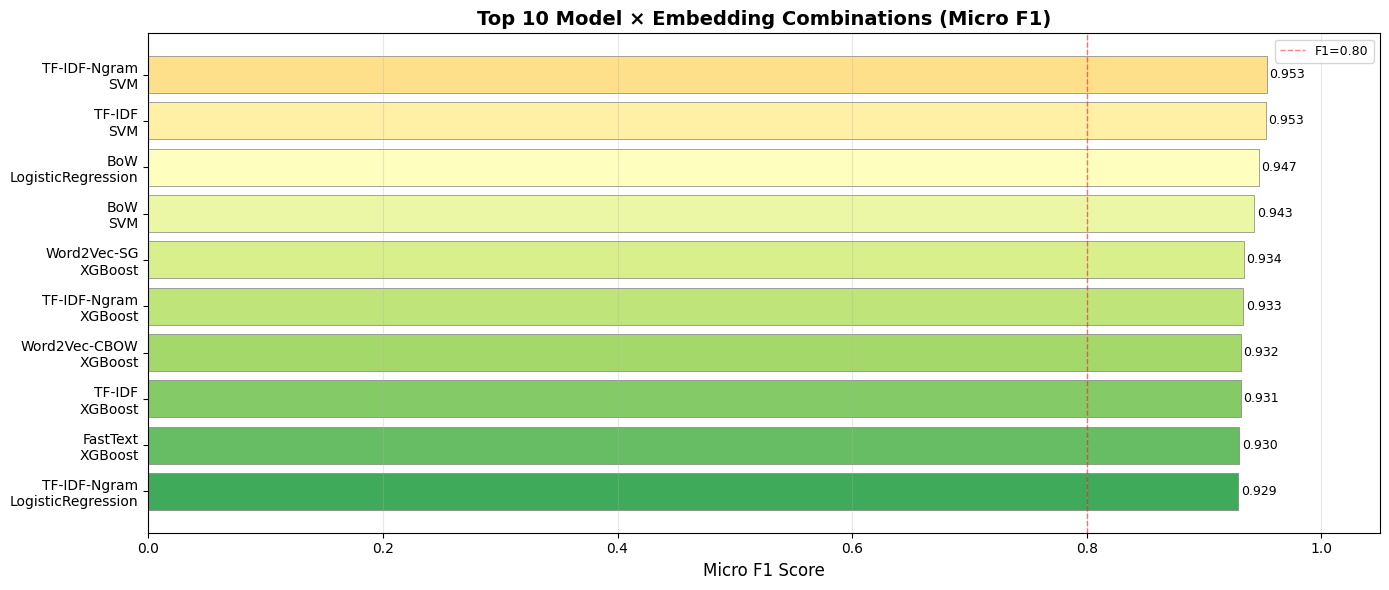

Saved: top10_models.png


In [16]:
top10 = results_df.head(10).copy()
top10['label'] = top10['Embedding'] + '\n' + top10['Model']

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.RdYlGn(np.linspace(0.4, 0.85, len(top10)))
bars = ax.barh(top10['label'][::-1], top10['Micro_F1'][::-1],
               color=colors[::-1], edgecolor='grey', linewidth=0.5)

for bar, val in zip(bars, top10['Micro_F1'][::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('Micro F1 Score', fontsize=12)
ax.set_title('Top 10 Model × Embedding Combinations (Micro F1)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.05)
ax.axvline(0.8, color='red', linestyle='--', linewidth=1, alpha=0.5, label='F1=0.80')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('top10_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: top10_models.png')

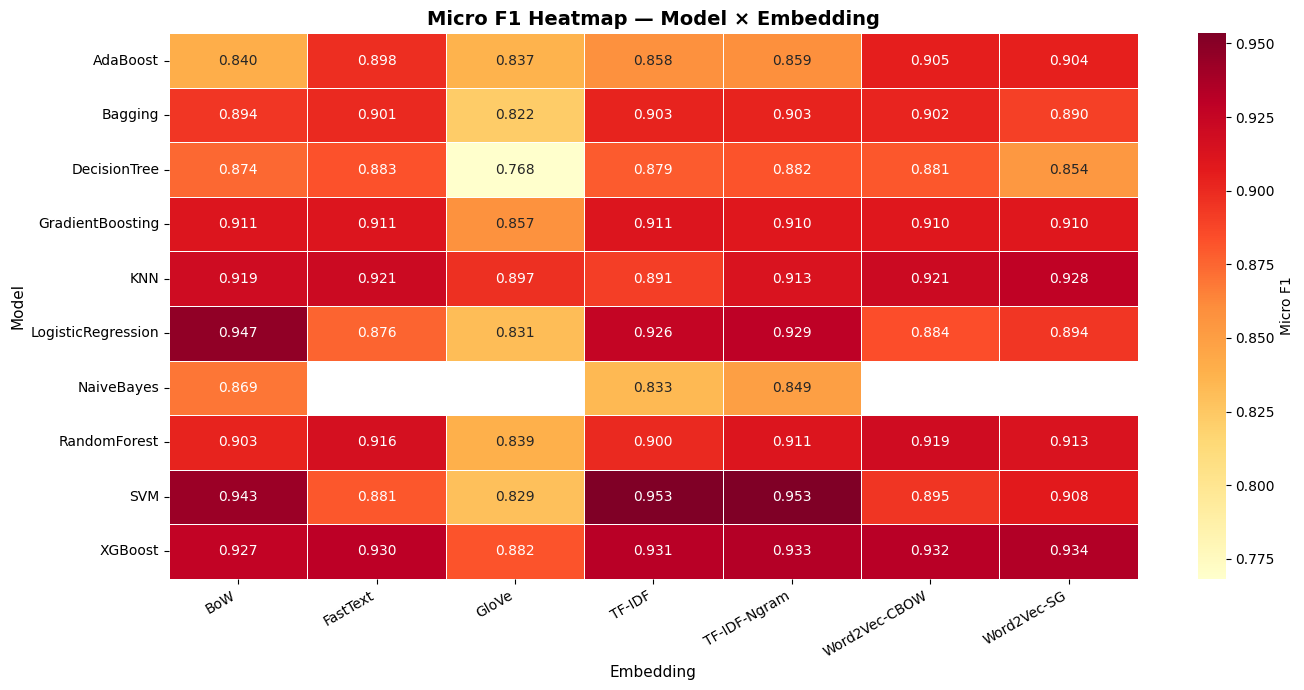

Saved: heatmap_f1.png


In [17]:
pivot = results_df.pivot_table(
    index='Model', columns='Embedding', values='Micro_F1', aggfunc='max'
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    pivot, annot=True, fmt='.3f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'Micro F1'}
)
ax.set_title('Micro F1 Heatmap — Model × Embedding', fontsize=14, fontweight='bold')
ax.set_xlabel('Embedding', fontsize=11)
ax.set_ylabel('Model', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('heatmap_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: heatmap_f1.png')

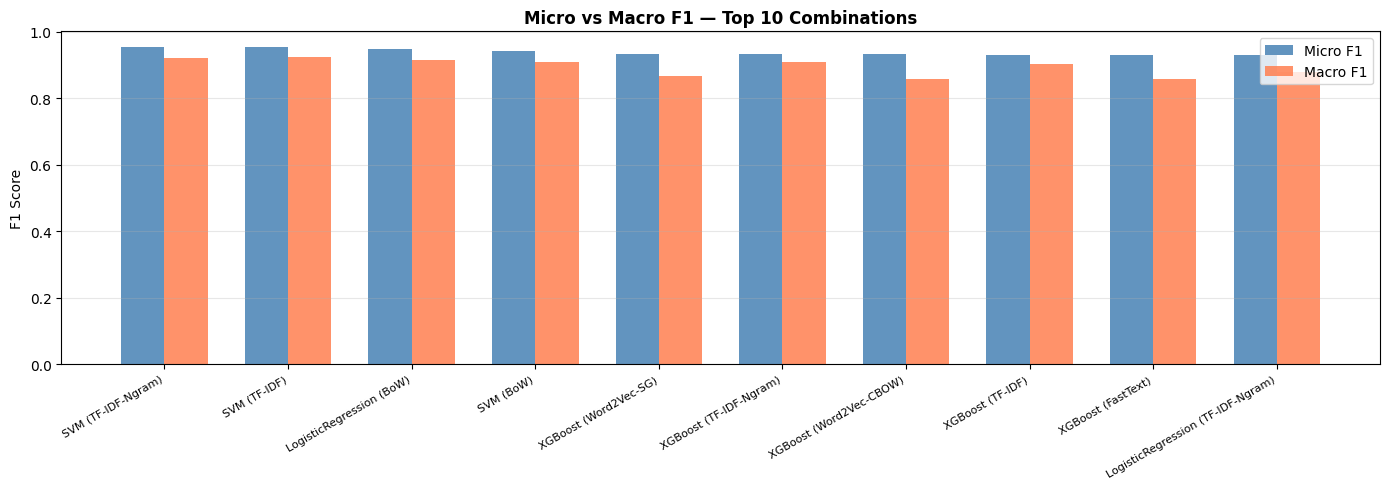

In [18]:
top10_plot = results_df.head(10).copy()
top10_plot['label'] = top10_plot['Model'] + ' (' + top10_plot['Embedding'] + ')'

x = np.arange(len(top10_plot))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - w/2, top10_plot['Micro_F1'], w, label='Micro F1', color='steelblue', alpha=0.85)
ax.bar(x + w/2, top10_plot['Macro_F1'], w, label='Macro F1', color='coral',     alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(top10_plot['label'], rotation=30, ha='right', fontsize=8)
ax.set_ylabel('F1 Score')
ax.set_title('Micro vs Macro F1 — Top 10 Combinations', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('micro_vs_macro.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Best Model — Full Report

In [19]:
best_row = ALL_RESULTS[0]  
best_row = max(ALL_RESULTS, key=lambda r: r['Micro_F1'])

print('╔' + '═'*50 + '╗')
print(f'║  BEST COMBINATION')
print(f'║  Embedding : {best_row["Embedding"]}')
print(f'║  Model     : {best_row["Model"]}')
print(f'║  Accuracy  : {best_row["Accuracy"]:.4f}')
print(f'║  Micro F1  : {best_row["Micro_F1"]:.4f}')
print(f'║  Macro F1  : {best_row["Macro_F1"]:.4f}')
print('╚' + '═'*50 + '╝')

# Full classification report
print('\n── Classification Report (Best Model) ──')
print(classification_report(
    Y_test, best_row['_Y_pred'],
    target_names=mlb.classes_, zero_division=0
))

╔══════════════════════════════════════════════════╗
║  BEST COMBINATION
║  Embedding : TF-IDF-Ngram
║  Model     : SVM
║  Accuracy  : 0.9111
║  Micro F1  : 0.9534
║  Macro F1  : 0.9212
╚══════════════════════════════════════════════════╝

── Classification Report (Best Model) ──
              precision    recall  f1-score   support

         acq       0.96      0.99      0.97       492
        corn       0.88      0.92      0.90        49
       crude       0.90      0.94      0.92       126
        earn       0.99      0.98      0.98       792
       grain       0.93      0.93      0.93       124
    interest       0.82      0.94      0.88        98
    money-fx       0.86      0.93      0.90       163
        ship       1.00      0.82      0.90        61
       trade       0.92      0.98      0.95        96
       wheat       0.86      0.90      0.88        61

   micro avg       0.95      0.96      0.95      2062
   macro avg       0.91      0.93      0.92      2062
weighted avg   

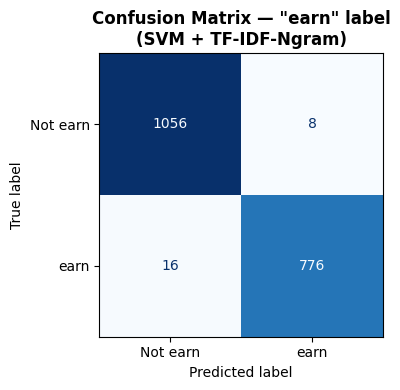

In [20]:
LABEL_IDX = list(mlb.classes_).index('earn')  

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(Y_test[:, LABEL_IDX], best_row['_Y_pred'][:, LABEL_IDX])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not earn', 'earn'])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — "earn" label\n({best_row["Model"]} + {best_row["Embedding"]})',
             fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_earn.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Hyperparameter Tuning (Top Models)

In [21]:
X_tr_tfidf, X_va_tfidf, X_te_tfidf = TRAD_EMBEDS['TF-IDF']

print('── Tuning LinearSVC ──')
svm_pipe = Pipeline([
    ('clf', OneVsRestClassifier(LinearSVC(max_iter=2000, class_weight='balanced',
                                           random_state=42)))
])
svm_grid = {'clf__estimator__C': [0.1, 0.5, 1.0, 5.0]}

svm_gs = GridSearchCV(
    svm_pipe, svm_grid,
    scoring='f1_micro', cv=3, n_jobs=-1, verbose=1
)
svm_gs.fit(X_tr_tfidf, Y_train)
print(f'Best SVM C: {svm_gs.best_params_}')
print(f'Best SVM CV Micro-F1: {svm_gs.best_score_:.4f}')

Y_pred_svm_tuned = svm_gs.predict(X_te_tfidf)
metrics_svm = evaluate(Y_test, Y_pred_svm_tuned)
print(f'Tuned SVM Test → Micro-F1={metrics_svm["Micro_F1"]:.4f}  Macro-F1={metrics_svm["Macro_F1"]:.4f}')

── Tuning LinearSVC ──
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best SVM C: {'clf__estimator__C': 1.0}
Best SVM CV Micro-F1: 0.9465
Tuned SVM Test → Micro-F1=0.9528  Macro-F1=0.9244


In [22]:
print('── Tuning Logistic Regression ──')
lr_pipe = Pipeline([
    ('clf', OneVsRestClassifier(LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    )))
])
lr_grid = {
    'clf__estimator__C':       [0.1, 0.5, 1.0, 5.0],
    'clf__estimator__solver':  ['lbfgs', 'saga'],
}
lr_gs = GridSearchCV(
    lr_pipe, lr_grid,
    scoring='f1_micro', cv=3, n_jobs=-1, verbose=1
)
lr_gs.fit(X_tr_tfidf, Y_train)
print(f'Best LR params: {lr_gs.best_params_}')
print(f'Best LR CV Micro-F1: {lr_gs.best_score_:.4f}')

Y_pred_lr_tuned = lr_gs.predict(X_te_tfidf)
metrics_lr = evaluate(Y_test, Y_pred_lr_tuned)
print(f'Tuned LR Test → Micro-F1={metrics_lr["Micro_F1"]:.4f}  Macro-F1={metrics_lr["Macro_F1"]:.4f}')

── Tuning Logistic Regression ──
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

Best LR params: {'clf__estimator__C': 5.0, 'clf__estimator__solver': 'lbfgs'}
Best LR CV Micro-F1: 0.9405
Tuned LR Test → Micro-F1=0.9447  Macro-F1=0.9127


In [23]:
# ── Add tuned results to comparison table ────────────────────────────────
tuned_rows = [
    {'Embedding': 'TF-IDF (tuned)', 'Model': 'SVM',
     'Accuracy': round(accuracy_score(Y_test, Y_pred_svm_tuned), 4),
     'Micro_F1': round(metrics_svm['Micro_F1'], 4),
     'Macro_F1': round(metrics_svm['Macro_F1'], 4), 'Time_s': '-'},
    {'Embedding': 'TF-IDF (tuned)', 'Model': 'LogisticRegression',
     'Accuracy': round(accuracy_score(Y_test, Y_pred_lr_tuned), 4),
     'Micro_F1': round(metrics_lr['Micro_F1'], 4),
     'Macro_F1': round(metrics_lr['Macro_F1'], 4), 'Time_s': '-'},
]
results_df = pd.concat([results_df, pd.DataFrame(tuned_rows)], ignore_index=True)
results_df.sort_values('Micro_F1', ascending=False, inplace=True)
results_df.reset_index(drop=True, inplace=True)

print('Final leaderboard (top 15):')
results_df[['Embedding','Model','Accuracy','Micro_F1','Macro_F1']].head(15)

Final leaderboard (top 15):


,Embedding,Model,Accuracy,Micro_F1,Macro_F1
0,TF-IDF-Ngram,SVM,0.9111,0.9534,0.9212
1,TF-IDF,SVM,0.9122,0.9528,0.9244
2,TF-IDF (tuned),SVM,0.9122,0.9528,0.9244
3,BoW,LogisticRegression,0.9014,0.9465,0.9139
4,TF-IDF (tuned),LogisticRegression,0.8939,0.9447,0.9127
5,BoW,SVM,0.8982,0.9429,0.9087
6,Word2Vec-SG,XGBoost,0.8863,0.9340,0.8673
7,TF-IDF-Ngram,XGBoost,0.8745,0.9335,0.9076
8,Word2Vec-CBOW,XGBoost,0.8820,0.9317,0.8574
9,TF-IDF,XGBoost,0.8707,0.9313,0.9041


## 8. Embedding Quality — Silhouette Analysis

Computing silhouette scores (this takes ~1 min)...
  BoW                  silhouette = 0.172
  TF-IDF               silhouette = 0.1383
  TF-IDF-Ngram         silhouette = 0.1262
  Word2Vec-CBOW        silhouette = 0.2678999900817871
  Word2Vec-SG          silhouette = 0.21330000460147858
  FastText             silhouette = 0.2054000049829483
  GloVe                silhouette = 0.09549999982118607


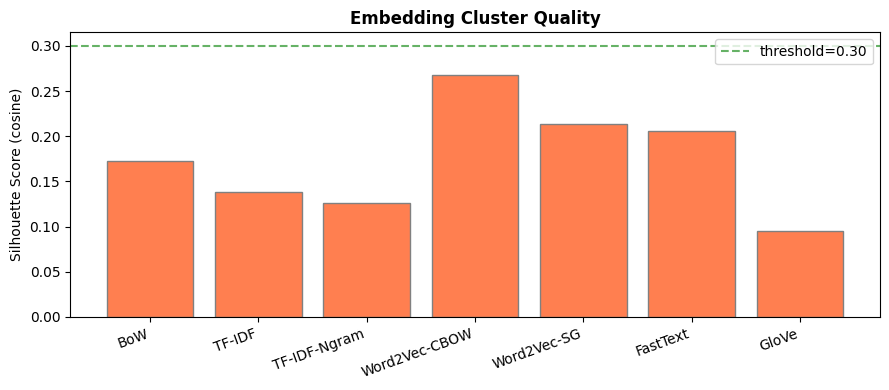

In [24]:
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize

def silhouette_for_embedding(X, Y_binary, n_components=50, sample=2000):
    labels_single = Y_binary.argmax(axis=1)

    if issparse(X):
        reducer = TruncatedSVD(n_components=n_components, random_state=42)
    else:
        reducer = PCA(n_components=min(n_components, X.shape[1]), random_state=42)
    X_red = reducer.fit_transform(X)

    # Sample for speed
    n = min(sample, X_red.shape[0])
    idx = np.random.choice(X_red.shape[0], n, replace=False)
    X_s, y_s = X_red[idx], labels_single[idx]

    # Normalize for cosine
    X_s = normalize(X_s)

    score = silhouette_score(X_s, y_s, metric='cosine')
    return round(score, 4)


print('Computing silhouette scores (this takes ~1 min)...')
sil_results = {}

for name, (X_tr, _, _) in TRAD_EMBEDS.items():
    s = silhouette_for_embedding(X_tr, Y_train)
    sil_results[name] = s
    print(f'  {name:<20} silhouette = {s}')

for name, (X_tr, _, _) in DENSE_EMBEDS.items():
    s = silhouette_for_embedding(X_tr, Y_train)
    sil_results[name] = s
    print(f'  {name:<20} silhouette = {s}')

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
names = list(sil_results.keys())
scores = list(sil_results.values())
colors = ['steelblue' if s > 0.3 else 'coral' for s in scores]
ax.bar(names, scores, color=colors, edgecolor='grey')
ax.set_ylabel('Silhouette Score (cosine)')
ax.set_title('Embedding Cluster Quality', fontweight='bold')
ax.axhline(0.3, color='green', linestyle='--', alpha=0.6, label='threshold=0.30')
ax.legend()
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Final Summary

In [25]:
print('='*65)
print('FINAL RESULTS SUMMARY')
print('='*65)
print(results_df[['Embedding','Model','Accuracy','Micro_F1','Macro_F1']]
      .head(20).to_string(index=True))

best = results_df.iloc[0]
print(f'\nBest combination:')
print(f'   Embedding : {best["Embedding"]}')
print(f'   Model     : {best["Model"]}')
print(f'   Micro F1  : {best["Micro_F1"]}')
print(f'   Macro F1  : {best["Macro_F1"]}')

print(f'\nEmbedding silhouette scores:')
for k, v in sorted(sil_results.items(), key=lambda x: -x[1]):
    print(f'  {k:<20} {v}')

print('\nPipeline complete.')

FINAL RESULTS SUMMARY
         Embedding               Model  Accuracy  Micro_F1  Macro_F1
0     TF-IDF-Ngram                 SVM    0.9111    0.9534    0.9212
1           TF-IDF                 SVM    0.9122    0.9528    0.9244
2   TF-IDF (tuned)                 SVM    0.9122    0.9528    0.9244
3              BoW  LogisticRegression    0.9014    0.9465    0.9139
4   TF-IDF (tuned)  LogisticRegression    0.8939    0.9447    0.9127
5              BoW                 SVM    0.8982    0.9429    0.9087
6      Word2Vec-SG             XGBoost    0.8863    0.9340    0.8673
7     TF-IDF-Ngram             XGBoost    0.8745    0.9335    0.9076
8    Word2Vec-CBOW             XGBoost    0.8820    0.9317    0.8574
9           TF-IDF             XGBoost    0.8707    0.9313    0.9041
10        FastText             XGBoost    0.8809    0.9302    0.8570
11    TF-IDF-Ngram  LogisticRegression    0.8669    0.9292    0.8799
12     Word2Vec-SG                 KNN    0.8820    0.9284    0.8618
13          